<h1 align="center">Практическая работа№9</h1>

<h1 align="center">Ход работы</h1>

1. Выбрать на kaggle.com любой датасет с неразмеченными данными (или просто убрать метку). Признаков должно быть не меньше 6, а экземпляров - не меньше 200. Присоединенный винный датасет подойдет.
2. Перевести все значения признаков в числа и шкалировать.
3. Произвести кластеризацию по методу k средних на оптимальное для этого датасета число кластеров. Обосновать выбор оптимального числа кластеров.
4. Произвести восходящую кластеризацию. (На защите буду спрашивать, в частности, что является критерием остановки алгоритма восходящей кластеризации)
5. Сравнить результаты кластеризации, полученные разными методами. Требуется количественное сравнение!
6. Опишите полученные результаты с точки зрения практического применения.

Форма данных: (1596, 12)
Столбцы: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


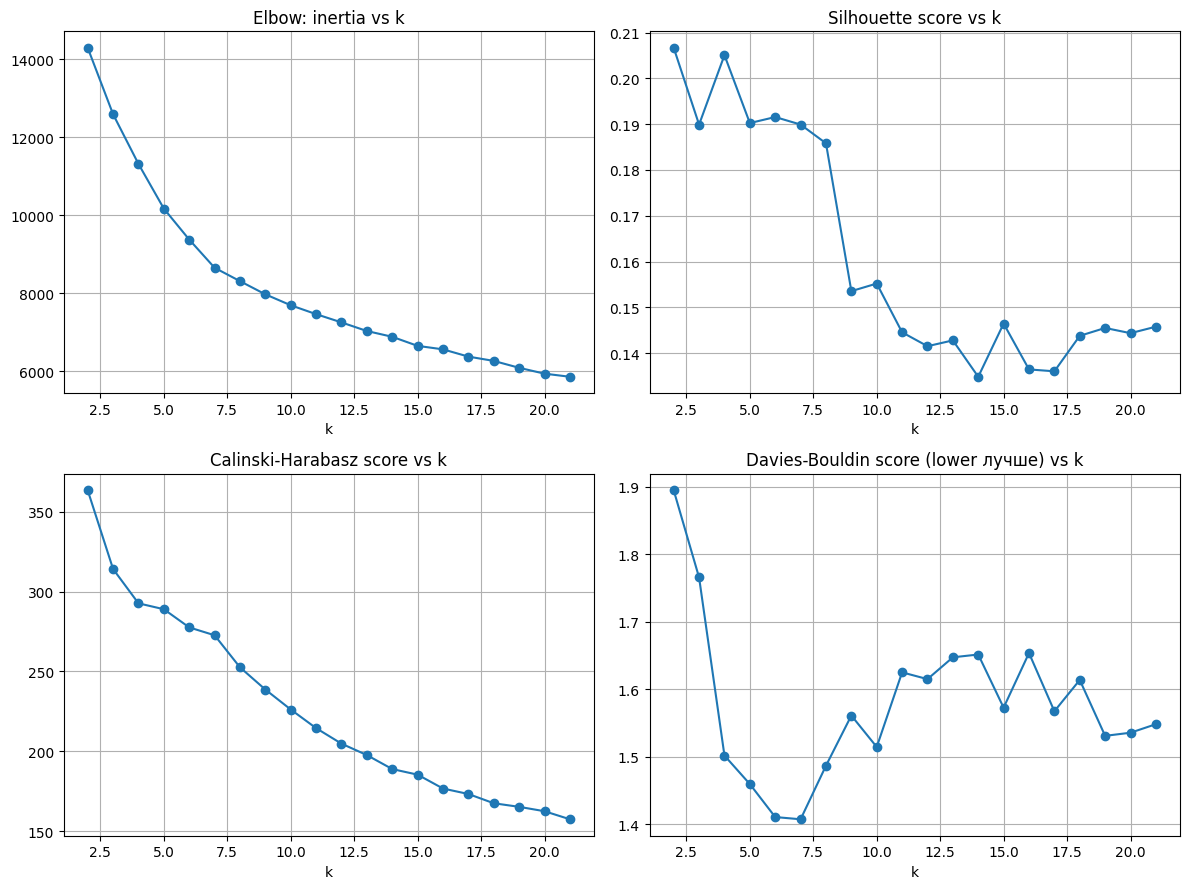

Лучшее k по Silhouette: 2
Лучшее k по Calinski-Harabasz: 2
Выбранное число кластеров для KMeans: 2


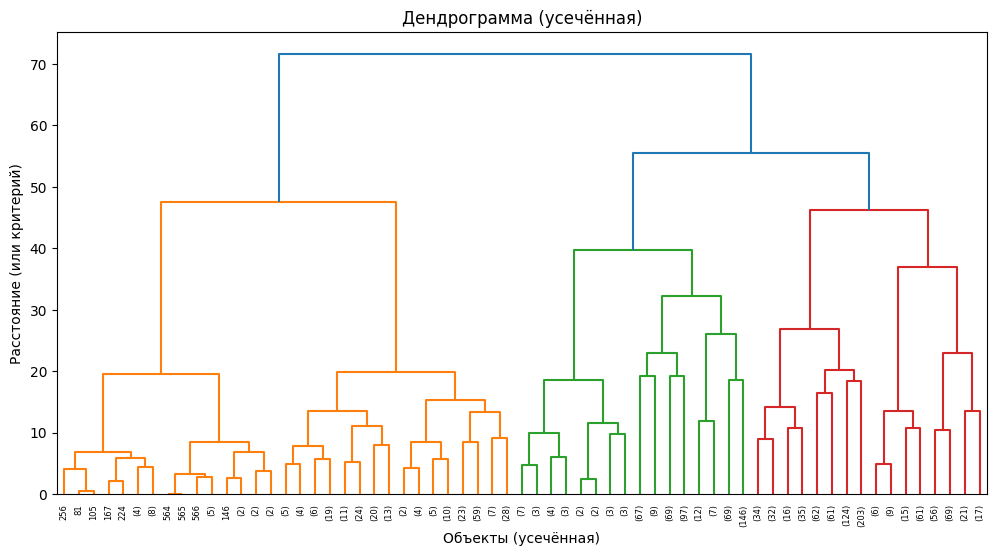

Агломеративная кластеризация: получено кластеров: 2
Пример порога для остановки (по наибольшему разрыву): 55.5762
Число кластеров при останове по порогу: 2

Метрики KMeans (k=2):
 {'n_clusters': 2, 'silhouette': 0.206686102112151, 'calinski_harabasz': 363.3878712276403, 'davies_bouldin': 1.8950173179416216}
Метрики Agglomerative (n_clusters=2):
 {'n_clusters': 2, 'silhouette': 0.23313802944835713, 'calinski_harabasz': 272.4015892285825, 'davies_bouldin': 1.6663649851416782}
Метрики Agglomerative (threshold stop, n_clusters=2):
 {'n_clusters': 2, 'silhouette': 0.23313802944835713, 'calinski_harabasz': 272.4015892285825, 'davies_bouldin': 1.6663649851416782}

Adjusted Rand Index (KMeans vs Agglomerative k): 0.2826956754314086
Adjusted Rand Index (KMeans vs Agglomerative threshold): 0.2826956754314086
Adjusted Rand Index (Agglomerative k vs threshold): 1.0


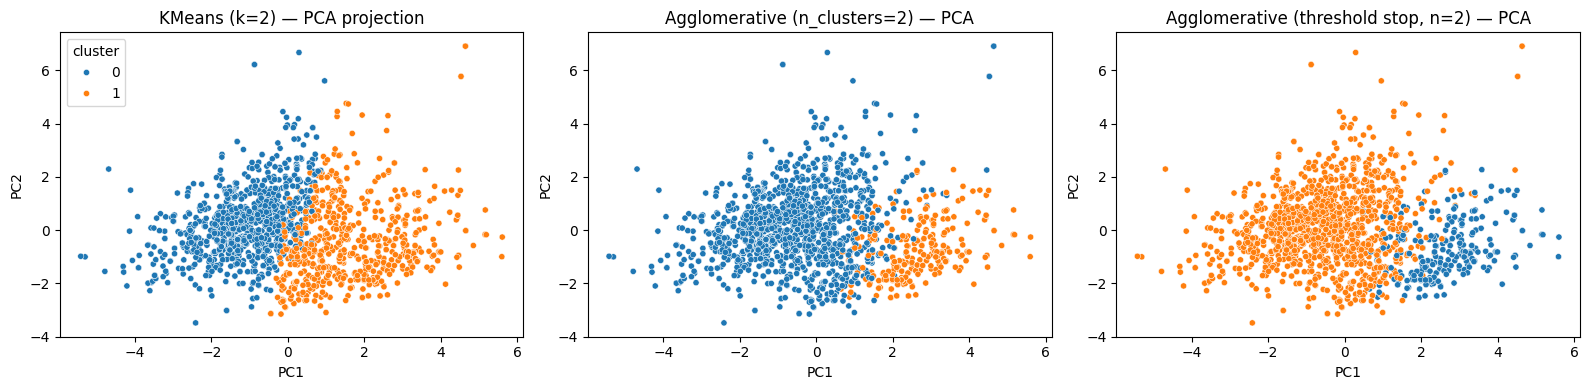

Результаты сохранены в clustering_results.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import warnings
warnings.filterwarnings("ignore")

CSV_PATH = "winequality-red.csv" 
df = pd.read_csv(CSV_PATH)
print("Форма данных:", df.shape)
print("Столбцы:", df.columns.tolist())

# -------------------------
# 2) Привести все значения признаков в числа и шкалировать
# -------------------------
# Если есть нечисловые столбцы — переводим в числа (one-hot или label encoding).
# Однако в винном датасете признаки уже числовые. Ниже — общий код.

# Отделяем признаки (X). Если в датасете есть столбец 'quality' (метка), мы его удаляем,
# т.к. условие задачи — неразмеченные данные. Но можно сохранить для анализа.
if 'quality' in df.columns:
    y_quality = df['quality'].copy()
    X = df.drop(columns=['quality'])
else:
    y_quality = None
    X = df.copy()

# Приведём non-numeric при необходимости:
for col in X.columns:
    if X[col].dtype == 'object':
        # простая обработка категориальных: one-hot
        X = pd.get_dummies(X, columns=[col], drop_first=True)

# Проверка количества признаков и экземпляров
n_samples, n_features = X.shape
assert n_features >= 6, "Требуется >=6 признаков"
assert n_samples >= 200, "Требуется >=200 экземпляров"

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 3) K-means: поиск оптимального числа кластеров
#    (обоснование: Elbow, Silhouette, Calinski-Harabasz)
# -------------------------
max_k = 21
inertia = []
sil_scores = []
ch_scores = []
db_scores = []

K_range = range(2, max_k + 1)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Визуализация критериев
plt.figure(figsize=(12, 9))
plt.subplot(2,2,1)
plt.plot(K_range, inertia, '-o')
plt.title('Elbow: inertia vs k')
plt.xlabel('k'); plt.grid(True)

plt.subplot(2,2,2)
plt.plot(K_range, sil_scores, '-o')
plt.title('Silhouette score vs k')
plt.xlabel('k'); plt.grid(True)

plt.subplot(2,2,3)
plt.plot(K_range, ch_scores, '-o')
plt.title('Calinski-Harabasz score vs k')
plt.xlabel('k'); plt.grid(True)

plt.subplot(2,2,4)
plt.plot(K_range, db_scores, '-o')
plt.title('Davies-Bouldin score (lower лучше) vs k')
plt.xlabel('k'); plt.grid(True)

plt.tight_layout()
plt.show()

# Автовыбор k: можно ориентироваться на максимум Silhouette и CH, а также локальный "локоть" по inertia.
best_k_sil = K_range[int(np.argmax(sil_scores))]
best_k_ch = K_range[int(np.argmax(ch_scores))]
# Для наглядности:
print("Лучшее k по Silhouette:", best_k_sil)
print("Лучшее k по Calinski-Harabasz:", best_k_ch)

# Выберем окончательное k как консенсус (если совпадают — хорошо, иначе используем силу аргументации).
# Здесь возьмём k_sil (обычно более информативно для плотности кластеров).
k_opt = best_k_sil
print("Выбранное число кластеров для KMeans:", k_opt)

kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=50)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

# -------------------------
# 4) Восходящая (агломеративная) кластеризация
#    - построим дендрограмму
#    - продемонстрируем критерии остановки

# Для дендрограммы используем linkage (метод 'ward' — минимизация внутрикластовой дисперсии)
Z = linkage(X_scaled, method='ward')  

# Plot dendrogram (может быть медленно при большом N; для наглядности — показать усечённую)
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # усечённая для читаемости
plt.title('Дендрограмма (усечённая)')
plt.xlabel('Объекты (усечённая)')
plt.ylabel('Расстояние (или критерий)')
plt.show()

# Критерий остановки агломеративной кластеризации:
# - можно задать желаемое число кластеров (n_clusters), тогда алгоритм объединяет до этого числа;
# - либо задать порог по расстоянию (distance_threshold): перестаём объединять, когда расстояние слияния > threshold.
#
# Здесь продемонстрируем оба подхода: 1) останов по числу кластеров = k_opt (для сравнения); 
# 2) найти "естественный" порог: посмотреть на большие скачки в Z[:,2] (расстояния объединения).

# 1) Соглано k_opt
agg_k = AgglomerativeClustering(n_clusters=k_opt, linkage='ward')
labels_agg_k = agg_k.fit_predict(X_scaled)
print("Агломеративная кластеризация: получено кластеров:", len(np.unique(labels_agg_k)))

# 2) По порогу: ищем резкий скачок в последовательности расстояний
distances = Z[:, 2]
# находим наиболее большой разрыв между соседними расстояниями
delta = np.diff(distances)
biggest_gap_idx = np.argmax(delta)
threshold = distances[biggest_gap_idx]  # пример порога
print(f"Пример порога для остановки (по наибольшему разрыву): {threshold:.4f}")

# Получим кластеризацию, отрезая дендрограмму по этому порогу (fcluster)
# fcluster использует критерий 'distance' для порога. k будет не фиксирован.
labels_agg_thresh = fcluster(Z, t=threshold, criterion='distance') - 1  # привести к 0-based
n_clusters_thresh = len(np.unique(labels_agg_thresh))
print("Число кластеров при останове по порогу:", n_clusters_thresh)

# -------------------------
# 5) Сравнение результатов (количественное)
#    - Silhouette, CH, DB для KMeans и Agglomerative
#    - ARI между кластеризациями (т.к. меток нет — ARI между методами)
def cluster_metrics(X, labels):
    out = {}
    out['n_clusters'] = len(np.unique(labels))
    if out['n_clusters'] > 1 and out['n_clusters'] < len(X):
        out['silhouette'] = silhouette_score(X, labels)
        out['calinski_harabasz'] = calinski_harabasz_score(X, labels)
        out['davies_bouldin'] = davies_bouldin_score(X, labels)
    else:
        out['silhouette'] = np.nan
        out['calinski_harabasz'] = np.nan
        out['davies_bouldin'] = np.nan
    return out

metrics_kmeans = cluster_metrics(X_scaled, labels_kmeans)
metrics_agg_k = cluster_metrics(X_scaled, labels_agg_k)
metrics_agg_thresh = cluster_metrics(X_scaled, labels_agg_thresh)

print("\nМетрики KMeans (k=%d):\n" % k_opt, metrics_kmeans)
print("Метрики Agglomerative (n_clusters=%d):\n" % len(np.unique(labels_agg_k),), metrics_agg_k)
print("Метрики Agglomerative (threshold stop, n_clusters=%d):\n" % len(np.unique(labels_agg_thresh),), metrics_agg_thresh)

# ARI между кластеризациями (количественное сравнение)
ari_km_vs_aggk = adjusted_rand_score(labels_kmeans, labels_agg_k)
ari_km_vs_aggth = adjusted_rand_score(labels_kmeans, labels_agg_thresh)
ari_aggk_vs_aggth = adjusted_rand_score(labels_agg_k, labels_agg_thresh)

print("\nAdjusted Rand Index (KMeans vs Agglomerative k):", ari_km_vs_aggk)
print("Adjusted Rand Index (KMeans vs Agglomerative threshold):", ari_km_vs_aggth)
print("Adjusted Rand Index (Agglomerative k vs threshold):", ari_aggk_vs_aggth)

# -------------------------
# 6) Визуализация кластеров (PCA 2D) для наглядности
# -------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(16, 4))
plt.subplot(1,3,1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_kmeans, palette='tab10', s=20)
plt.title(f'KMeans (k={k_opt}) — PCA projection'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(title='cluster', loc='best')

plt.subplot(1,3,2)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_agg_k, palette='tab10', s=20)
plt.title(f'Agglomerative (n_clusters={len(np.unique(labels_agg_k))}) — PCA'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend([],[], frameon=False)

plt.subplot(1,3,3)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_agg_thresh, palette='tab10', s=20)
plt.title(f'Agglomerative (threshold stop, n={len(np.unique(labels_agg_thresh))}) — PCA'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend([],[], frameon=False)

plt.tight_layout()
plt.show()

# Сохранение результатов в CSV для дальнейшего разбора (опционально)
out_df = X.copy()
out_df['kmeans_cluster'] = labels_kmeans
out_df['agg_k_cluster'] = labels_agg_k
out_df['agg_thresh_cluster'] = labels_agg_thresh
out_df.to_csv('clustering_results.csv', index=False)
print("Результаты сохранены в clustering_results.csv")
